In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Robust project root
def find_project_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / ".gitignore").exists() and (parent / "data").exists():
            return parent
    raise RuntimeError(f"Could not find project root from {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "report"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)

# ==== load data ====
X_cqt = np.load(PROCESSED_DIR / "windows_cqt.npy")
metadata_df = pd.read_parquet(PROCESSED_DIR / "windows_metadata.parquet")
X_features_classical = np.load(PROCESSED_DIR / "windows_features_classical.npy")

y_all = metadata_df["class_id"].to_numpy()
NUM_CLASSES = int(y_all.max()) + 1
id_to_name = dict(zip(metadata_df["class_id"], metadata_df["class_name"]))
target_names = [id_to_name[i] for i in sorted(id_to_name.keys())]

train_mask = (metadata_df["split"] == "train").to_numpy()
val_mask = (metadata_df["split"] == "val").to_numpy()
test_mask = (metadata_df["split"] == "test").to_numpy()

# ==== rebuild the CNN class + Dataset (needed to load state_dict) ====
class ChordCNN(nn.Module):
    def __init__(self, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 1))
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=(2, 2))
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.global_pool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)


class ChordDataset(Dataset):
    def __init__(self, X_cqt: np.ndarray, y: np.ndarray):
        X_normalized = (X_cqt + 80.0) / 80.0
        self.X = torch.from_numpy(X_normalized).unsqueeze(1).contiguous()
        self.y = torch.from_numpy(y).long()

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]


# ==== load augmented CNN checkpoint + run predictions ====
val_ds = ChordDataset(X_cqt[val_mask], y_all[val_mask])
test_ds = ChordDataset(X_cqt[test_mask], y_all[test_mask])

model = ChordCNN(num_classes=NUM_CLASSES).to(DEVICE)
checkpoint = torch.load(MODELS_DIR / "cnn_augmented_best.pt",
                        map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

def predict(dataset: ChordDataset) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
    y_true, y_pred, y_proba = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            y_true.append(y.numpy())
            y_pred.append(logits.argmax(dim=1).cpu().numpy())
            y_proba.append(probs.cpu().numpy())
    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_proba)

y_val_true, y_val_pred_cnn, y_val_proba_cnn = predict(val_ds)
y_test_true, y_test_pred_cnn, y_test_proba_cnn = predict(test_ds)

print(f"Loaded CNN from epoch {checkpoint['epoch']}, val_acc {checkpoint['val_acc']:.3f}")
print(f"Val:  X_cqt shape {X_cqt[val_mask].shape}, predictions {y_val_pred_cnn.shape}")
print(f"Test: X_cqt shape {X_cqt[test_mask].shape}, predictions {y_test_pred_cnn.shape}")

# ==== retrain RF for comparison (needed here for probability outputs) ====
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=2, class_weight="balanced",
    n_jobs=-1, random_state=42,
)
rf.fit(X_features_classical[train_mask], y_all[train_mask])
y_val_pred_rf = rf.predict(X_features_classical[val_mask])
y_val_proba_rf = rf.predict_proba(X_features_classical[val_mask])
y_test_pred_rf = rf.predict(X_features_classical[test_mask])
y_test_proba_rf = rf.predict_proba(X_features_classical[test_mask])

print(f"\nRF retrained. RF val_proba shape: {y_val_proba_rf.shape}")

Loaded CNN from epoch 11, val_acc 0.645
Val:  X_cqt shape (3513, 84, 22), predictions (3513,)
Test: X_cqt shape (3506, 84, 22), predictions (3506,)

RF retrained. RF val_proba shape: (3513, 37)


In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize

# Binarize labels into one-hot for one-vs-rest metric computation
y_val_onehot = np.asarray(label_binarize(y_val_true, classes=np.arange(NUM_CLASSES)))
y_test_onehot = np.asarray(label_binarize(y_test_true, classes=np.arange(NUM_CLASSES)))

# Per-class ROC-AUC — explicit np.ndarray cast because sklearn's return type is dynamic
val_auc_rf_per_class = np.asarray(
    roc_auc_score(y_val_onehot, y_val_proba_rf, average=None)
)
val_auc_cnn_per_class = np.asarray(
    roc_auc_score(y_val_onehot, y_val_proba_cnn, average=None)
)

# Macro/micro averages — explicit float cast
val_auc_rf_macro = float(roc_auc_score(y_val_onehot, y_val_proba_rf, average="macro"))
val_auc_rf_micro = float(roc_auc_score(y_val_onehot, y_val_proba_rf, average="micro"))
val_auc_cnn_macro = float(roc_auc_score(y_val_onehot, y_val_proba_cnn, average="macro"))
val_auc_cnn_micro = float(roc_auc_score(y_val_onehot, y_val_proba_cnn, average="micro"))

test_auc_rf_macro = float(roc_auc_score(y_test_onehot, y_test_proba_rf, average="macro"))
test_auc_cnn_macro = float(roc_auc_score(y_test_onehot, y_test_proba_cnn, average="macro"))

print(f"{'Metric':<30} {'RF':>12} {'CNN+aug':>12}")
print("-" * 56)
print(f"{'Val ROC-AUC (macro)':<30} {val_auc_rf_macro:>12.4f} {val_auc_cnn_macro:>12.4f}")
print(f"{'Val ROC-AUC (micro)':<30} {val_auc_rf_micro:>12.4f} {val_auc_cnn_micro:>12.4f}")
print(f"{'Test ROC-AUC (macro)':<30} {test_auc_rf_macro:>12.4f} {test_auc_cnn_macro:>12.4f}")

print(f"\nPer-class ROC-AUC (val set):")
print(f"{'Class':<14} {'RF AUC':>10} {'CNN AUC':>10} {'Δ':>10}")
print("-" * 46)
for cid in range(NUM_CLASSES):
    name = id_to_name[cid]
    delta = val_auc_cnn_per_class[cid] - val_auc_rf_per_class[cid]
    print(f"{name:<14} {val_auc_rf_per_class[cid]:>10.3f} "
          f"{val_auc_cnn_per_class[cid]:>10.3f} {delta:>+10.3f}")

Metric                                   RF      CNN+aug
--------------------------------------------------------
Val ROC-AUC (macro)                  0.9359       0.9644
Val ROC-AUC (micro)                  0.9523       0.9678
Test ROC-AUC (macro)                 0.9184       0.9464

Per-class ROC-AUC (val set):
Class              RF AUC    CNN AUC          Δ
----------------------------------------------
note:C              1.000      0.998     -0.001
note:C#             0.999      0.999     +0.000
note:D              1.000      0.998     -0.002
note:D#             1.000      1.000     -0.000
note:E              1.000      1.000     -0.000
note:F              1.000      0.999     -0.001
note:F#             1.000      0.997     -0.003
note:G              1.000      1.000     -0.000
note:G#             0.998      0.997     -0.001
note:A              1.000      1.000     +0.000
note:A#             1.000      0.999     -0.000
note:B              0.999      0.999     +0.000
maj:C         

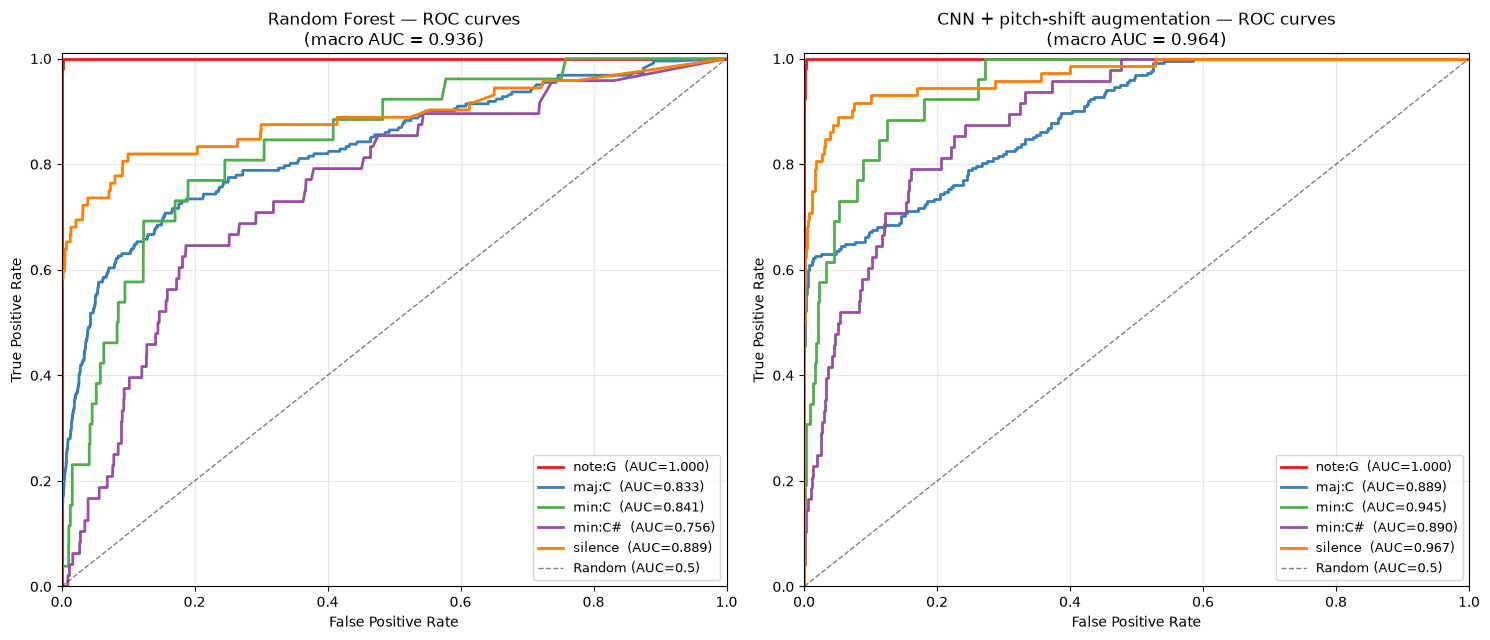


Saved to c:\Users\Constantine\Code\ml-project\report\roc_curves_comparison.png


In [5]:
from sklearn.metrics import roc_curve
from itertools import cycle

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# Choose a small set of interesting classes to show — otherwise 37 curves is chaos
# Pick: one of each type + the biggest wins
interesting_ids = [
    7,   # note:G (very high AUC)
    12,  # maj:C
    24,  # min:C (big CNN win)
    25,  # min:C# (biggest CNN win)
    36,  # silence
]
interesting_names = [id_to_name[i] for i in interesting_ids]

# Color palette
colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

# --- Left: RF ---
for cid, color, name in zip(interesting_ids, colors, interesting_names):
    fpr, tpr, _ = roc_curve(y_val_onehot[:, cid], y_val_proba_rf[:, cid])
    auc_val = val_auc_rf_per_class[cid]
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name}  (AUC={auc_val:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random (AUC=0.5)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"Random Forest — ROC curves\n(macro AUC = {val_auc_rf_macro:.3f})")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.01)

# --- Right: CNN + aug ---
for cid, color, name in zip(interesting_ids, colors, interesting_names):
    fpr, tpr, _ = roc_curve(y_val_onehot[:, cid], y_val_proba_cnn[:, cid])
    auc_val = val_auc_cnn_per_class[cid]
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name}  (AUC={auc_val:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random (AUC=0.5)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"CNN + pitch-shift augmentation — ROC curves\n(macro AUC = {val_auc_cnn_macro:.3f})")
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.01)

plt.tight_layout()
fig.savefig(REPORT_DIR / "roc_curves_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nSaved to {REPORT_DIR / 'roc_curves_comparison.png'}")

Metric                                   RF      CNN+aug
--------------------------------------------------------
Val PR-AUC (macro)                   0.6227       0.7177
Val PR-AUC (micro)                   0.6139       0.6938


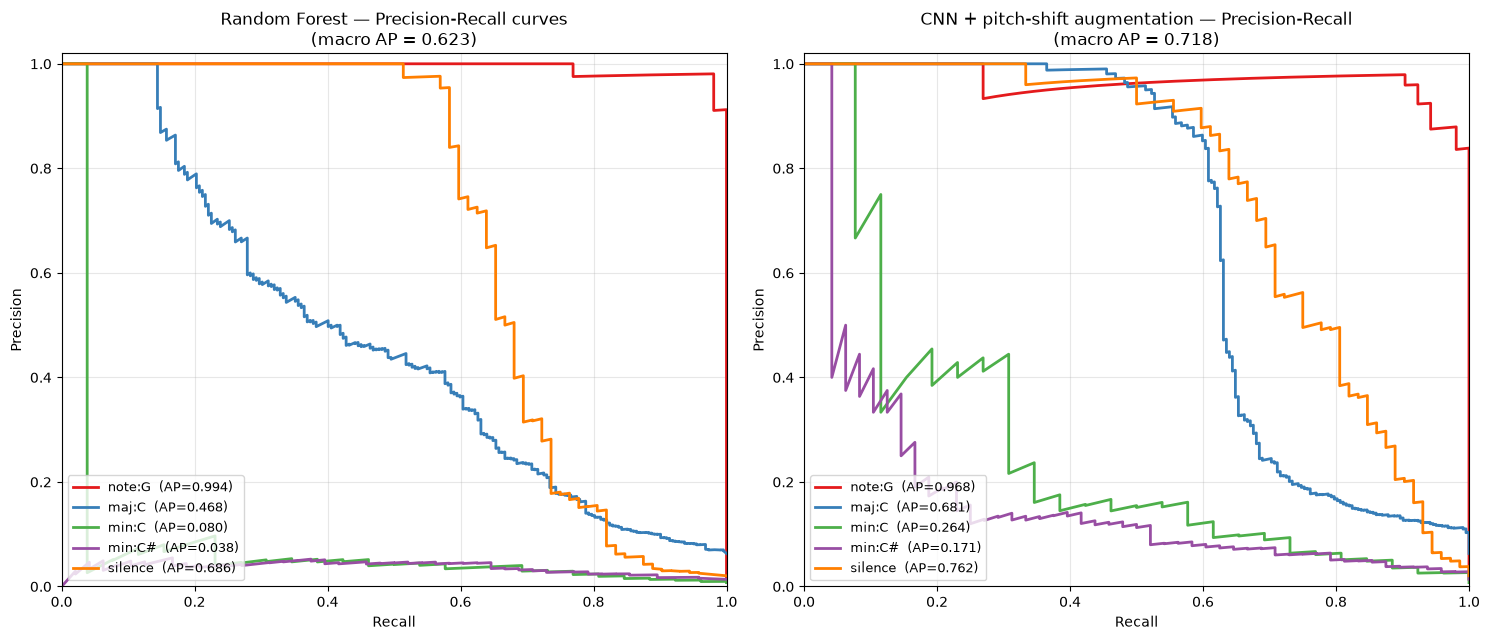


Saved to c:\Users\Constantine\Code\ml-project\report\pr_curves_comparison.png


In [6]:
from sklearn.metrics import precision_recall_curve

# PR-AUC (average precision) per class
val_ap_rf_per_class = np.array([
    average_precision_score(y_val_onehot[:, cid], y_val_proba_rf[:, cid])
    for cid in range(NUM_CLASSES)
])
val_ap_cnn_per_class = np.array([
    average_precision_score(y_val_onehot[:, cid], y_val_proba_cnn[:, cid])
    for cid in range(NUM_CLASSES)
])

val_ap_rf_macro = float(val_ap_rf_per_class.mean())
val_ap_cnn_macro = float(val_ap_cnn_per_class.mean())

# Also compute test macro PR-AUC
val_ap_rf_micro = float(average_precision_score(y_val_onehot, y_val_proba_rf, average="micro"))
val_ap_cnn_micro = float(average_precision_score(y_val_onehot, y_val_proba_cnn, average="micro"))

print(f"{'Metric':<30} {'RF':>12} {'CNN+aug':>12}")
print("-" * 56)
print(f"{'Val PR-AUC (macro)':<30} {val_ap_rf_macro:>12.4f} {val_ap_cnn_macro:>12.4f}")
print(f"{'Val PR-AUC (micro)':<30} {val_ap_rf_micro:>12.4f} {val_ap_cnn_micro:>12.4f}")


# PR curves plot — same 5 interesting classes as before
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for cid, color, name in zip(interesting_ids, colors, interesting_names):
    precision, recall, _ = precision_recall_curve(y_val_onehot[:, cid], y_val_proba_rf[:, cid])
    ap = val_ap_rf_per_class[cid]
    axes[0].plot(recall, precision, color=color, linewidth=2,
                 label=f"{name}  (AP={ap:.3f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Random Forest — Precision-Recall curves\n(macro AP = {val_ap_rf_macro:.3f})")
axes[0].legend(loc="lower left", fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)

for cid, color, name in zip(interesting_ids, colors, interesting_names):
    precision, recall, _ = precision_recall_curve(y_val_onehot[:, cid], y_val_proba_cnn[:, cid])
    ap = val_ap_cnn_per_class[cid]
    axes[1].plot(recall, precision, color=color, linewidth=2,
                 label=f"{name}  (AP={ap:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"CNN + pitch-shift augmentation — Precision-Recall\n(macro AP = {val_ap_cnn_macro:.3f})")
axes[1].legend(loc="lower left", fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
fig.savefig(REPORT_DIR / "pr_curves_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nSaved to {REPORT_DIR / 'pr_curves_comparison.png'}")

                Accuracy  Macro F1  Macro ROC-AUC  Macro PR-AUC
RF (val)          0.5727    0.5971         0.9359        0.6227
CNN+aug (val)     0.6453    0.6696         0.9644        0.7177
RF (test)         0.5408    0.5549         0.9184        0.5898
CNN+aug (test)    0.6326    0.6486         0.9464        0.6864

Saved to c:\Users\Constantine\Code\ml-project\report\final_metrics_summary.csv


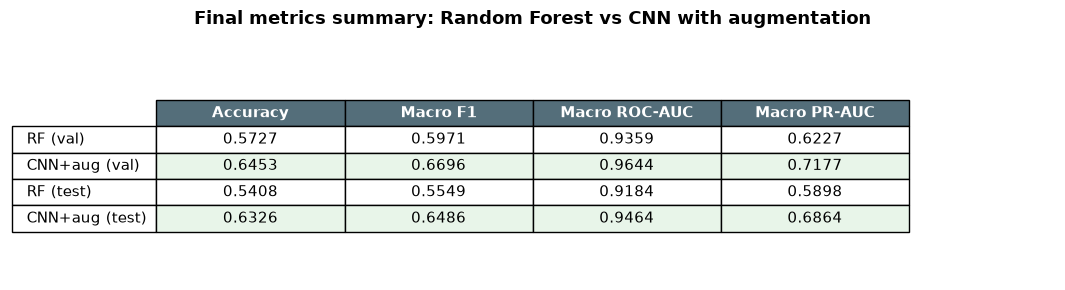

Saved to c:\Users\Constantine\Code\ml-project\report\final_metrics_table.png


In [7]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# ==== Recompute all metrics per model for a single clean table ====

def summarize(y_true: np.ndarray, y_pred: np.ndarray,
              y_proba: np.ndarray, y_onehot: np.ndarray) -> dict:
    """Return dict of headline metrics for a model."""
    acc = float(accuracy_score(y_true, y_pred))
    prfs = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    f1_per_class = np.asarray(prfs[2])
    macro_f1 = float(f1_per_class.mean())
    auc_macro = float(roc_auc_score(y_onehot, y_proba, average="macro"))
    ap_macro = float(np.asarray([
        average_precision_score(y_onehot[:, cid], y_proba[:, cid])
        for cid in range(NUM_CLASSES)
    ]).mean())
    return {
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Macro ROC-AUC": auc_macro,
        "Macro PR-AUC": ap_macro,
    }


results = {
    "RF (val)":       summarize(y_val_true,  y_val_pred_rf,  y_val_proba_rf,  y_val_onehot),
    "CNN+aug (val)":  summarize(y_val_true,  y_val_pred_cnn, y_val_proba_cnn, y_val_onehot),
    "RF (test)":      summarize(y_test_true, y_test_pred_rf, y_test_proba_rf, y_test_onehot),
    "CNN+aug (test)": summarize(y_test_true, y_test_pred_cnn, y_test_proba_cnn, y_test_onehot),
}

summary_df = pd.DataFrame(results).T.round(4)
print(summary_df.to_string())

# Save as CSV
summary_csv = REPORT_DIR / "final_metrics_summary.csv"
summary_df.to_csv(summary_csv)
print(f"\nSaved to {summary_csv}")

# Render as matplotlib table for presentation
fig, ax = plt.subplots(figsize=(11, 3))
ax.axis("off")

# Convert to list-of-lists for matplotlib (Pylance-clean and matches doc)
cell_text = [[f"{v:.4f}" for v in row] for row in summary_df.values.tolist()]
row_labels = list(summary_df.index)
col_labels = list(summary_df.columns)

table = ax.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    colWidths=[0.15] * len(col_labels),
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.6)

# Highlight CNN rows
for row_idx, row_label in enumerate(row_labels):
    is_cnn_row = "CNN" in row_label
    for col_idx in range(len(col_labels)):
        cell = table[(row_idx + 1, col_idx)]
        if is_cnn_row:
            cell.set_facecolor("#e8f5e9")

# Header styling
for col_idx in range(len(col_labels)):
    header_cell = table[(0, col_idx)]
    header_cell.set_facecolor("#546e7a")
    header_cell.set_text_props(weight="bold", color="white")

ax.set_title("Final metrics summary: Random Forest vs CNN with augmentation",
             fontsize=13, weight="bold", pad=20)
plt.tight_layout()
fig.savefig(REPORT_DIR / "final_metrics_table.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved to {REPORT_DIR / 'final_metrics_table.png'}")